# Object Detection Model Comparison Lab
## Comparing YOLOv8-nano and YOLOv11-nano on COCO128 Dataset

## Setup and Environment Check

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm

## Set seeds for reproducibility

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

## Create directories for outputs

In [3]:
os.makedirs('data_splits', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

## Load COCO128 Dataset

Downloads the COCO128 dataset if not already present.
Returns the path to the dataset.

In [4]:
from ultralytics import YOLO

# Function to download and check COCO128 dataset
def download_coco128():
    from ultralytics.utils.downloads import download
    
    # Create datasets directory if it doesn't exist
    os.makedirs('datasets', exist_ok=True)
    
    # Download COCO128 dataset
    coco128_dir = Path('datasets/coco128')
    if not coco128_dir.exists():
        print("Downloading COCO128 dataset...")
        # Use ultralytics downloader to get COCO128
        download(url='https://ultralytics.com/assets/coco128.zip', dir='datasets/')
    else:
        print("COCO128 dataset already exists.")
    
    # Verify dataset structure
    img_dir = coco128_dir / 'images' / 'train2017'
    label_dir = coco128_dir / 'labels' / 'train2017'
    
    if img_dir.exists() and label_dir.exists():
        num_images = len(list(img_dir.glob('*.jpg')))
        num_labels = len(list(label_dir.glob('*.txt')))
        
        print(f"Dataset structure verified. Found {num_images} images and {num_labels} labels.")
        
        if num_images == 0 or num_labels == 0:
            print("Warning: Dataset appears to be empty or incomplete.")
            
            print("Checking if dataset was correctly extracted...")
        
        return coco128_dir.absolute()
    else:
        raise FileNotFoundError("Dataset structure is not as expected. Please check the dataset directory.")

# Download and check the dataset
coco_path = download_coco128()


100%|██████████████████████████████████████| 6.66M/6.66M [00:00<00:00, 49.6MB/s]
Unzipping datasets/coco128.zip to /Users/kimhaeseong/CAU_25_Spring_ComputerVisio

Dataset structure verified. Found 128 images and 128 labels.


## Collect and Organize Dataset Information
Collects and organizes information about the dataset.
Returns a DataFrame with image paths and corresponding label paths.

In [5]:
def collect_dataset_info(dataset_path):
    img_dir = dataset_path / 'images' / 'train2017'
    label_dir = dataset_path / 'labels' / 'train2017'
    
    image_files = sorted(list(img_dir.glob('*.jpg')))
    
    data = []
    for img_path in image_files:
        img_name = img_path.stem
        label_path = label_dir / f"{img_name}.txt"
        
        # Only include images that have corresponding labels
        if label_path.exists():
            data.append({
                'image_path': str(img_path),
                'label_path': str(label_path),
                'image_id': img_name
            })
    
    # Create DataFrame
    df = pd.DataFrame(data)
    print(f"Total valid images with labels: {len(df)}")
    
    return df

# Collect dataset info
dataset_df = collect_dataset_info(coco_path)
dataset_df.head()


Total valid images with labels: 126


,image_path,label_path,image_id
0,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,000000000009
1,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,000000000025
2,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,000000000030
3,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,000000000034
4,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,/Users/kimhaeseong/CAU_25_Spring_ComputerVisio...,000000000036


## Create 10 Data Splits for Cross-Validation
Creates n_splits of the dataset using ShuffleSplit with a 6:2:2 ratio for train:val:test.
Saves each split as a CSV file and returns the list of split files.

In [6]:
def create_data_splits(df, n_splits=5, seed=42):
    from sklearn.model_selection import ShuffleSplit
    
    # List to store results
    split_files = []
    
    # Total number of data samples
    n_samples = len(df)
    
    # Use ShuffleSplit for each split
    for i in range(n_splits):
        split_num = i + 1
        
        # First split the entire data into 80%(train+val) and 20%(test)
        test_size = 0.2  # 20% of the entire data for test set
        train_val_size = 0.8  # 80% of the entire data for train+val set
        
        # First ShuffleSplit to separate train+val and test
        ss_test = ShuffleSplit(n_splits=1, test_size=test_size, random_state=seed+i)
        train_val_idx, test_idx = next(ss_test.split(df))
        
        # Split train+val data into train(75%) and val(25%) again
        # (75% of train+val is 60% of the entire data, 25% is 20% of the entire data)
        train_val_df = df.iloc[train_val_idx]
        # Create explicit copy
        test_df = df.iloc[test_idx].copy()
        
        # Second ShuffleSplit to separate train and val
        ss_val = ShuffleSplit(n_splits=1, test_size=0.25, random_state=seed+i)  # 25% of train_val for val
        train_idx, val_idx = next(ss_val.split(train_val_df))
        
        # Create each split dataframe - all with explicit copies
        train_df = train_val_df.iloc[train_idx].copy()
        val_df = train_val_df.iloc[val_idx].copy()
        
        # Add 'split' column to each split - using .loc to safely set values
        train_df.loc[:, 'split'] = 'train'
        val_df.loc[:, 'split'] = 'val'
        test_df.loc[:, 'split'] = 'test'
        
        # Combine all splits
        split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
        
        # Save to CSV
        split_file = f'data_splits/split_{split_num}.csv'
        split_df.to_csv(split_file, index=False)
        split_files.append(split_file)
        
        # Print split information
        print(f"Split {split_num}:")
        print(f"  Training: {len(train_df)} images ({len(train_df)/n_samples:.1%})")
        print(f"  Validation: {len(val_df)} images ({len(val_df)/n_samples:.1%})")
        print(f"  Test: {len(test_df)} images ({len(test_df)/n_samples:.1%})")
        print(f"  Total: {len(split_df)} images")
    
    return split_files
# Create 10 data splits
split_files = create_data_splits(dataset_df, n_splits=5, seed=SEED)

Split 1:
  Training: 75 images (59.5%)
  Validation: 25 images (19.8%)
  Test: 26 images (20.6%)
  Total: 126 images
Split 2:
  Training: 75 images (59.5%)
  Validation: 25 images (19.8%)
  Test: 26 images (20.6%)
  Total: 126 images
Split 3:
  Training: 75 images (59.5%)
  Validation: 25 images (19.8%)
  Test: 26 images (20.6%)
  Total: 126 images
Split 4:
  Training: 75 images (59.5%)
  Validation: 25 images (19.8%)
  Test: 26 images (20.6%)
  Total: 126 images
Split 5:
  Training: 75 images (59.5%)
  Validation: 25 images (19.8%)
  Test: 26 images (20.6%)
  Total: 126 images


## Define Utility Functions for YOLO Training and Evaluation
Creates a YAML configuration file for YOLO training based on the split file.
Returns the path to the created YAML file.

In [7]:
def prepare_yaml_config(split_file, split_num, model_name):
    # Load the split CSV
    split_df = pd.read_csv(split_file)
    
    # Get train, validation, and test sets
    train_df = split_df[split_df['split'] == 'train']
    val_df = split_df[split_df['split'] == 'val']
    test_df = split_df[split_df['split'] == 'test']
    
    # Create directory for data_splits
    os.makedirs('data_splits', exist_ok=True)
    
    # Create temporary txt files listing the absolute paths
    for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        with open(f'data_splits/{name}_{split_num}.txt', 'w') as f:
            for img_path in df['image_path']:
                f.write(f"{img_path}\n")
    
    # Get current working directory for absolute paths
    current_dir = os.getcwd()
    
    # Create YAML config with absolute paths
    yaml_content = f"""
# COCO128 dataset configuration for split {split_num}
path: {str(coco_path.absolute())}  # dataset root dir
train: {os.path.join(current_dir, f'data_splits/train_{split_num}.txt')}  # train images (absolute path)
val: {os.path.join(current_dir, f'data_splits/val_{split_num}.txt')}  # val images (absolute path)
test: {os.path.join(current_dir, f'data_splits/test_{split_num}.txt')}  # test images (absolute path)
# Classes
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  71: sink
  72: refrigerator
  73: book
  74: clock
  75: vase
  76: scissors
  77: teddy bear
  78: hair drier
  79: toothbrush
"""
    
    # Save YAML file
    yaml_path = f'data_splits/coco128_split_{split_num}_{model_name}.yaml'
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    return yaml_path

## Model Train
Trains a YOLO model using the specified configuration.
Returns the trained model, results, and training time.

In [8]:
def train_yolo_model(model_name, yaml_config, split_num, epochs=5):
    import time
    
    # Load pre-trained model
    if model_name == 'yolov8n':
        model = YOLO(f'{model_name}.pt')
    elif model_name == 'yolov5n':
        model = YOLO(f'{model_name}.pt')
    else:
        raise ValueError(f"Unsupported model version: {model_name}")
    
    # Set training device
    device = 'cpu'
    
    # Set path for saving training results
    project_dir = 'runs'
    run_name = f'{model_name}_split_{split_num}'
    
    # Record training start time
    start_time = time.time()
    
    # Train the model
    print(f"Training {model_name} on split {split_num} using {device}...")
    try:
        results = model.train(
            data=yaml_config,
            epochs=epochs,
            imgsz=640,
            batch=8,  # Smaller batch size for CPU
            device=device,
            workers=4,
            seed=SEED,
            patience=5,
            project=project_dir,
            name=run_name,
            exist_ok=True  # Overwrite existing run directory if it exists
        )
        
        # Record training end time and calculate training time (in hours)
        training_time = (time.time() - start_time) / 3600  # seconds -> hours conversion
        
        # Save the trained model as PT file
        model_save_path = f'models/{model_name}_split_{split_num}.pt'
        
        # Create model save directory if it doesn't exist
        os.makedirs('models', exist_ok=True)
        
        # Save model - using the default PT format
        model.save(model_save_path)
        print(f"Model saved to {model_save_path}")
        
        return model, results, training_time
    except Exception as e:
        print(f"Error during training: {e}")
        raise e  # Re-raise to be caught by the main function

## Model Evaluate
Evaluates a YOLO model on the test set.
Returns the evaluation metrics.

In [9]:
def evaluate_yolo_model(model, yaml_config, split_num):
    try:
        # Perform simplified evaluation
        results = model.val(data=yaml_config)
        
        # Convert results directly into a dictionary
        metrics_dict = {
            'split': split_num,
            'precision': 0.0, 
            'recall': 0.0,    
            'mAP50': 0.0,     
            'mAP50-95': 0.0   
        }
        
        # Extract results based on different metric formats per model
        import numpy as np
        # If results object is a dictionary
        if isinstance(results, dict):
            if 'metrics/precision(B)' in results:
                metrics_dict['precision'] = float(np.mean(results['metrics/precision(B)']))
            if 'metrics/recall(B)' in results:
                metrics_dict['recall'] = float(np.mean(results['metrics/recall(B)']))
            if 'metrics/mAP50(B)' in results:
                metrics_dict['mAP50'] = float(np.mean(results['metrics/mAP50(B)']))
            if 'metrics/mAP50-95(B)' in results:
                metrics_dict['mAP50-95'] = float(np.mean(results['metrics/mAP50-95(B)']))
        # If results object has attributes
        elif hasattr(results, 'box'):
            box = results.box
            if hasattr(box, 'p'):
                metrics_dict['precision'] = float(np.mean(box.p)) if isinstance(box.p, (list, np.ndarray)) else float(box.p)
            if hasattr(box, 'r'):
                metrics_dict['recall'] = float(np.mean(box.r)) if isinstance(box.r, (list, np.ndarray)) else float(box.r)
            if hasattr(box, 'map50'):
                metrics_dict['mAP50'] = float(np.mean(box.map50)) if isinstance(box.map50, (list, np.ndarray)) else float(box.map50)
            if hasattr(box, 'map'):
                metrics_dict['mAP50-95'] = float(np.mean(box.map)) if isinstance(box.map, (list, np.ndarray)) else float(box.map)
    except Exception as inner_e:
        print(f"Warning: Error extracting metrics: {inner_e}")
    return metrics_dict

## Run Train and Evaluate
Runs the complete experiment for comparing object detection models.
Trains and evaluates each model on all data splits.
Returns a DataFrame with the evaluation results.

In [10]:
def run_experiment(models='yolov8n', splits=10, epochs=3):
    results = []
    
    model_name = models
    for split_num in range(1, splits + 1):
        print(f"\n{'='*50}")
        print(f"Processing {model_name} on split {split_num}")
        print(f"{'='*50}")
        # Prepare YAML config for this split
        yaml_config = prepare_yaml_config(
            f'data_splits/split_{split_num}.csv', 
            split_num, 
            model_name
        )
        try:
            # Train the model - 이제 training_time도 반환받음
            model, train_results, training_time = train_yolo_model(
                model_name,
                yaml_config,
                split_num,
                epochs=epochs
            )
            # Evaluate the model
            eval_metrics = evaluate_yolo_model(model, yaml_config, split_num)
            # Add model info to results
            eval_metrics['model'] = model_name
            eval_metrics['epochs'] = epochs
            eval_metrics['training_time'] = training_time
            
            # Add to results list
            results.append(eval_metrics)
            # Clean up to save memory
            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        except Exception as e:
            print(f"Error processing {model_name} on split {split_num}: {e}")
            continue
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_file = f'results/model_comparison_{timestamp}.csv'
    results_df.to_csv(results_file, index=False)
    
    return results_df

## Run the Experiment on YOLOv8-nano

In [11]:
results_df = run_experiment(
    models='yolov8n',
    splits=5,
    epochs=3
)

# Display results
print("\nExperiment Results:")
print(results_df)


Processing yolov8n on split 1
Training yolov8n on split 1 using cpu...
New https://pypi.org/project/ultralytics/8.3.101 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0 CPU (Apple M1)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=data_splits/coco128_split_1_yolov8n.yaml, epochs=3, time=None, patience=5, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=4, project=runs, name=yolov8n_split_1, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fals

train: Scanning /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/

train: New cache created: /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/coco128/labels/train2017.cache



val: Scanning /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/co

val: New cache created: /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/coco128/labels/train2017.cache
Plotting labels to runs/yolov8n_split_1/labels.jpg... 


...

Optimizer stripped from runs/yolov8n_split_5/weights/best.pt, 6.5MB

Validating runs/yolov8n_split_5/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0 CPU (Apple M1)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         25        149      0.593      0.742       0.73      0.575
                person         10         48      0.772      0.812      0.884      0.653
                   car          2          4      0.422       0.25       0.39      0.136
                 train          1          1      0.529          1      0.995      0.796
                 truck          1          1      0.816          1      0.995      0.995
                  boat          1          1          1          0      0.995      0.697
         traffic light          1          1          1          0          0          0
             stop sign          1          1      0.748          1      0.995      0.622
                 bench          1          1      0.364          1      0.995      0.895
                   cat          1          1      0.565          1      0.995      0.697
                   dog          2          2      0.785          1      0.995      0.532
              elephan

val: Scanning /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/co
                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         25        149      0.678      0.645      0.716      0.569
                person         10         48      0.919      0.712      0.882      0.652
                   car          2          4      0.501       0.25      0.364      0.233
                 train          1          1      0.628          1      0.995      0.796
                 truck          1          1          1          0      0.995      0.895
                  boat          1          1          1          0      0.995      0.697
         traffic light          1          1          1          0          0          0
             stop sign          1          1          1          0      0.497      0.448
                 bench          1          1      0.394          1      0.995      0.895
                   cat          1          1      0.632          1      0.995      0.697
                   dog          2          2      0.954          1      0.995      0.532
              elephan

## Run the Experiment on YOLOv5-nano

In [12]:
results_df = run_experiment(
    models='yolov5n',
    splits=5,
    epochs=3
)

# Display results
print("\nExperiment Results:")
print(results_df)


Processing yolov5n on split 1
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Training yolov5n on split 1 using cpu...
New https://pypi.org/project/ultralytics/8.3.101 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0 CPU (Apple M1)
engine/trainer: task=detect, mode=train, model=yolov5n.pt, data=data_splits/coco128_split_1_yolov5n.yaml, epochs=3, time=None, patience=5, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=4, project=runs, name=yolov5n_split_1, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mas

train: Scanning /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/

train: New cache created: /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/coco128/labels/train2017.cache



val: Scanning /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/co

val: New cache created: /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/coco128/labels/train2017.cache
Plotting labels to runs/yolov5n_split_1/labels.jpg... 


...

Optimizer stripped from runs/yolov5n_split_5/weights/last.pt, 5.6MB
Optimizer stripped from runs/yolov5n_split_5/weights/best.pt, 5.6MB

Validating runs/yolov5n_split_5/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0 CPU (Apple M1)
YOLOv5n summary (fused): 84 layers, 2,649,200 parameters, 0 gradients, 7.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         25        149      0.599       0.62      0.692      0.531
                person         10         48      0.879      0.812      0.875      0.604
                   car          2          4      0.336       0.25      0.365      0.289
                 train          1          1      0.442          1      0.995      0.895
                 truck          1          1          0          0      0.199      0.129
                  boat          1          1      0.967          1      0.995      0.995
         traffic light          1          1          1          0          0          0
             stop sign          1          1          1          0      0.995      0.697
                 bench          1          1      0.534          1      0.995      0.597
                   cat          1          1      0.375          1      0.995      0.697
                   dog          2          2          1      0.658      0.995      0.405
              elephan

val: Scanning /Users/kimhaeseong/CAU_25_Spring_ComputerVision/Week06/datasets/co
                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         25        149      0.599      0.621      0.675      0.526
                person         10         48      0.878      0.812      0.874      0.608
                   car          2          4      0.369       0.25      0.392       0.28
                 train          1          1      0.442          1      0.995      0.895
                 truck          1          1          0          0      0.199     0.0865
                  boat          1          1      0.967          1      0.995      0.995
         traffic light          1          1          1          0          0          0
             stop sign          1          1          1          0      0.995      0.796
                 bench          1          1      0.534          1      0.995      0.597
                   cat          1          1      0.375          1      0.995      0.697
                   dog          2          2          1      0.658      0.995      0.405
              elephan

## Analyze and Visualize Results
Analyzes the experiment results and creates visualizations.

In [24]:
# Loading saved result files
import glob
import pandas as pd

# Get all CSV files from the results folder
result_files = sorted(glob.glob('results/model_comparison_*.csv'))

# Find the most recent YOLOv5n and YOLOv8n result files
yolov5_file = None
yolov8_file = None

# Check each file to identify model type
for file in result_files:
    df = pd.read_csv(file)
    if 'model' in df.columns:
        if 'yolov5n' in df['model'].values and yolov5_file is None:
            yolov5_file = file
        if 'yolov8n' in df['model'].values and yolov8_file is None:
            yolov8_file = file
    
    # Stop if both are found
    if yolov5_file is not None and yolov8_file is not None:
        break

# Load data
df_yolov5 = pd.read_csv(yolov5_file) if yolov5_file else pd.DataFrame()
df_yolov8 = pd.read_csv(yolov8_file) if yolov8_file else pd.DataFrame()

# Merge data
results_combined = pd.concat([df_yolov5, df_yolov8], ignore_index=True)
print(f"Data loading completed: YOLOv5n ({len(df_yolov5)} rows), YOLOv8n ({len(df_yolov8)} rows)")
results_combined

데이터 불러오기 완료: YOLOv5n (5 rows), YOLOv8n (5 rows)


,split,precision,recall,mAP50,mAP50-95,model,epochs,training_time
0,1,0.6534,0.5661,0.6386,0.4922,yolov5n,3,0.0285
1,2,0.5455,0.4349,0.4981,0.3822,yolov5n,3,0.0301
2,3,0.8504,0.4620,0.6633,0.4893,yolov5n,3,0.0239
3,4,0.6218,0.4997,0.5897,0.4090,yolov5n,3,0.0257
4,5,0.5994,0.6212,0.6752,0.5265,yolov5n,3,0.0260
5,1,0.5463,0.6043,0.6726,0.4999,yolov8n,3,0.0269
6,2,0.6897,0.4622,0.5754,0.4327,yolov8n,3,0.0241
7,3,0.6601,0.6068,0.6804,0.5157,yolov8n,3,0.0237
8,4,0.8006,0.5034,0.6460,0.4776,yolov8n,3,0.0254
9,5,0.6777,0.6454,0.7162,0.5690,yolov8n,3,0.0228


In [25]:
# Create model performance summary table
summary_df = results_combined.groupby('model').agg({
    'mAP50': ['mean', 'std', 'min', 'max'],
    'mAP50-95': ['mean', 'std', 'min', 'max'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'training_time': ['mean', 'std', 'min', 'max']
})

# Convert multi-index columns to single level
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

# Output results
pd.set_option('display.float_format', '{:.4f}'.format)
print("YOLO Model Performance Comparison Summary:")
summary_df

YOLO 모델 성능 비교 요약:


,model,mAP50_mean,mAP50_std,mAP50_min,mAP50_max,mAP50-95_mean,mAP50-95_std,mAP50-95_min,mAP50-95_max,precision_mean,precision_std,recall_mean,recall_std,training_time_mean,training_time_std,training_time_min,training_time_max
0,yolov5n,0.6130,0.0721,0.4981,0.6752,0.4598,0.0612,0.3822,0.5265,0.6541,0.1166,0.5168,0.0764,0.0268,0.0024,0.0239,0.0301
1,yolov8n,0.6581,0.0526,0.5754,0.7162,0.4989,0.0501,0.4327,0.5690,0.6749,0.0905,0.5644,0.0776,0.0246,0.0016,0.0228,0.0269


In [26]:
%matplotlib inline

<Figure size 1000x600 with 0 Axes>

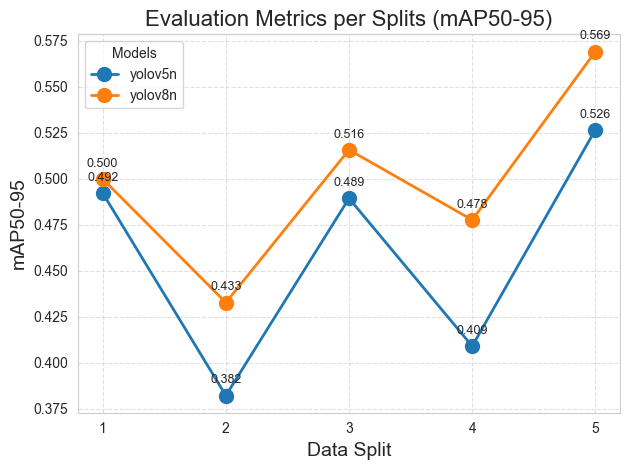

In [27]:
# mAP50-95 performance comparison by splits
plt.figure(figsize=(10, 6))

# Create pivot table
pivot_df = results_combined.pivot(index='split', columns='model', values='mAP50-95')

# Draw line graph
ax = pivot_df.plot(kind='line', marker='o', markersize=10, linewidth=2)

# Graph styling
plt.title('Evaluation Metrics per Splits (mAP50-95)', fontsize=16)
plt.xlabel('Data Split', fontsize=14)
plt.ylabel('mAP50-95', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(pivot_df.index)
plt.legend(title='Models')

# Display value at each data point
for model in pivot_df.columns:
    for i, value in enumerate(pivot_df[model]):
        plt.text(pivot_df.index[i], value + 0.005, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

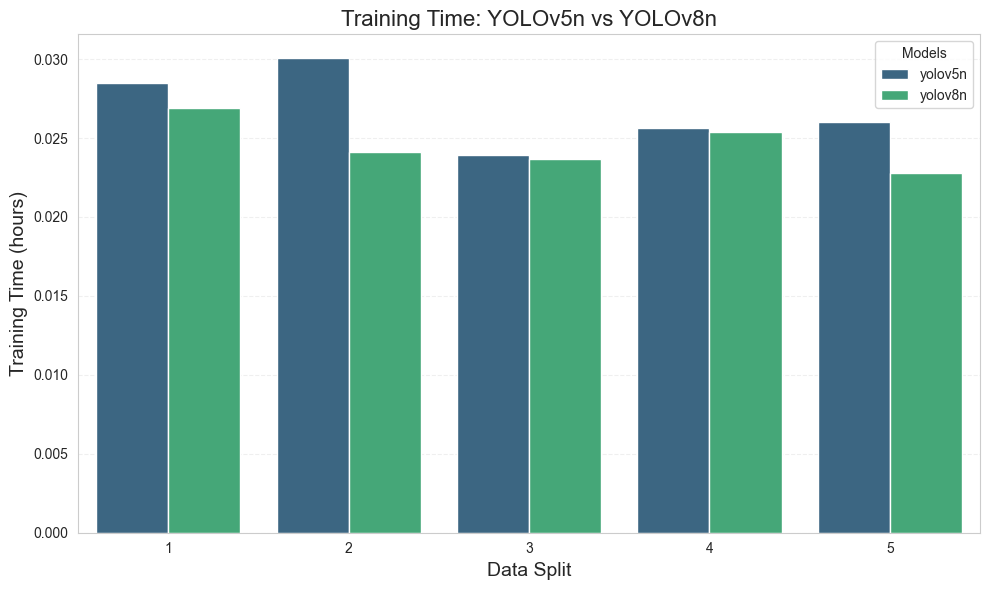

In [29]:
# Training time comparison visualization
plt.figure(figsize=(10, 6))

# Create grouped bar graph
sns.barplot(x='split', y='training_time', hue='model', data=results_combined, palette='viridis')

# Graph styling
plt.title('Training Time: YOLOv5n vs YOLOv8n', fontsize=16)
plt.xlabel('Data Split', fontsize=14)
plt.ylabel('Training Time (hours)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.legend(title='Models')

# Display values on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}h',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()